In [ ]:
from google.colab import files
import pandas as pd
import io

print(" Please upload your preprocessed wildfire dataset (.csv)")
uploaded = files.upload()

if not uploaded:
    raise ValueError(" No file uploaded. Please rerun and upload a CSV file.")

# Assuming the first uploaded file is the CSV dataset
CSV_PATH = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[CSV_PATH]))

print(f"✅ Uploaded File: {CSV_PATH}")
print("✅ Dataset Loaded — Shape:", df.shape)

# --- User Settings ---
TARGET_COL = "area"   # target variable for regression
TEST_SIZE = 0.2
RANDOM_STATE = 42
CATEGORICAL_COLS = []    # e.g., ['region','month']
RUN_TUNING = True        # set False to skip tuning

df.head()

📂 Please upload your preprocessed wildfire dataset (.csv)


Saving final_processed_pipeline.csv to final_processed_pipeline.csv
✅ Uploaded File: final_processed_pipeline.csv
✅ Dataset Loaded — Shape: (220, 6)


,DC,temp,DMC,RH,ISI,area
0,0.607908,0.354497,0.000000,0.327273,0.159664,0.0
1,0.653316,0.174603,0.048368,0.327273,0.159664,0.0
2,0.145918,0.576720,0.290793,0.254545,0.831933,0.0
3,0.165306,0.677249,0.311772,0.218182,0.310924,0.0
4,0.667857,0.095238,0.548368,0.872727,0.184874,0.0


 Please upload your preprocessed wildfire dataset (.csv)


Saving final_processed_pipeline.csv to final_processed_pipeline.csv
✅ Uploaded File: final_processed_pipeline.csv
✅ Dataset Loaded — Shape: (220, 6)
 Dataset loaded successfully: (220, 6)


,DC,temp,DMC,RH,ISI,area
0,0.607908,0.354497,0.000000,0.327273,0.159664,0.0
1,0.653316,0.174603,0.048368,0.327273,0.159664,0.0
2,0.145918,0.576720,0.290793,0.254545,0.831933,0.0
3,0.165306,0.677249,0.311772,0.218182,0.310924,0.0
4,0.667857,0.095238,0.548368,0.872727,0.184874,0.0



 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DC      220 non-null    float64
 1   temp    220 non-null    float64
 2   DMC     220 non-null    float64
 3   RH      220 non-null    float64
 4   ISI     220 non-null    float64
 5   area    220 non-null    float64
dtypes: float64(6)
memory usage: 10.4 KB
None


,count,mean,std,min,25%,50%,75%,max
DC,220.0,0.606320,0.223467,0.0,0.493367,0.652296,0.759694,1.00
temp,220.0,0.490308,0.195423,0.0,0.353175,0.481481,0.619048,1.00
DMC,220.0,0.480160,0.203305,0.0,0.358392,0.460373,0.598048,1.00
RH,220.0,0.473471,0.215364,0.0,0.327273,0.454545,0.600000,1.00
ISI,220.0,0.376547,0.226324,0.0,0.193277,0.336134,0.487395,1.00
area,220.0,1.220864,1.920072,0.0,0.000000,0.000000,1.787500,7.21


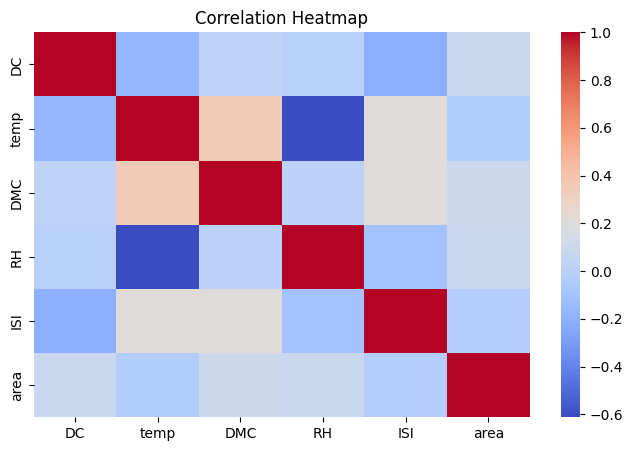


📦 Train shape: (176, 5) | Test shape: (44, 5)


In [3]:
# === 🔧 Minimal Preparation After Upload (for Decision Tree Regressor) ===
import seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from google.colab import files
import pandas as pd
import io

# Load the dataset
print(" Please upload your preprocessed wildfire dataset (.csv)")
uploaded = files.upload()

if not uploaded:
    raise ValueError(" No file uploaded. Please rerun and upload a CSV file.")

# Assuming the first uploaded file is the CSV dataset
CSV_PATH = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[CSV_PATH]))

print(f" Uploaded File: {CSV_PATH}")
print(" Dataset Loaded — Shape:", df.shape)

# --- User Settings ---
TARGET_COL = "area"   # target variable for regression
TEST_SIZE = 0.2
RANDOM_STATE = 42
CATEGORICAL_COLS = []    # e.g., ['region','month']
RUN_TUNING = True        # set False to skip tuning

#  1. Verify dataset
print(" Dataset loaded successfully:", df.shape)
display(df.head())

# 1️ Quick EDA verification
print("\n Dataset Info:")
print(df.info())
display(df.describe().T)

plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

#  2. Feature / Target Split
TARGET_COL = "area"   # Change this if your target column name is different
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

#  3. Train–Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"\n📦 Train shape: {X_train.shape} | Test shape: {X_test.shape}")

#  4. Common Evaluation Function
def evaluate_model(y_true, y_pred, name="Model"):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"\n{name} Results:")
    print(f"R²   = {r2:.4f}")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")
    return r2, mae, rmse

## 1. Imports

# --- Decision Tree Regressor (Base Model) ---

In [4]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np, seaborn as sns, matplotlib.pyplot as plt


In [5]:
# Step 1 – Create model
dt = DecisionTreeRegressor(random_state=42)

In [6]:
# Step 2 - Train model
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [7]:
# Step 3 – Predict
y_pred_dt = dt.predict(X_test)

In [8]:
# Step 4 – Evaluate metrics
r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print(" Decision Tree Regressor (Base Model):")
print(f"R² = {r2_dt:.4f}, MAE = {mae_dt:.4f}, RMSE = {rmse_dt:.4f}")


 Decision Tree Regressor (Base Model):
R² = -0.9724, MAE = 2.0363, RMSE = 2.9356


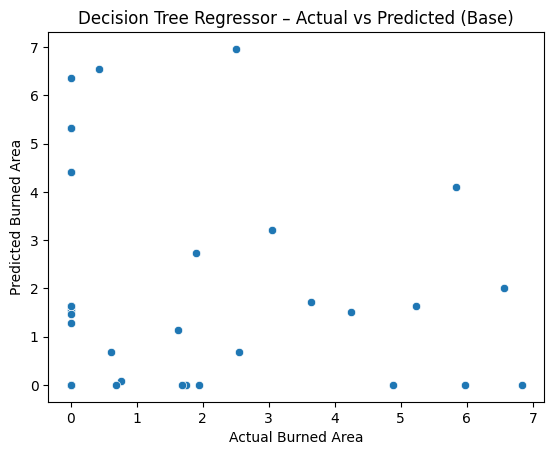

In [9]:
# Step 5 – Visualize Actual vs Predicted
sns.scatterplot(x=y_test, y=y_pred_dt)
plt.xlabel("Actual Burned Area")
plt.ylabel("Predicted Burned Area")
plt.title("Decision Tree Regressor – Actual vs Predicted (Base)")
plt.show()

Hyperparameter Tuning

In [10]:
from sklearn.model_selection import GridSearchCV

# --- Experiment 1 ---
param_grid_dt1 = {
    "criterion": ["squared_error", "friedman_mse"],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10]
}
grid_dt1 = GridSearchCV(DecisionTreeRegressor(random_state=42),
                        param_grid=param_grid_dt1, cv=5, scoring="r2", n_jobs=-1)
grid_dt1.fit(X_train, y_train)
print(" Best Params (Experiment 1):", grid_dt1.best_params_)
print("Best CV R²:", grid_dt1.best_score_)

# --- Experiment 2 (more fine-tuned) ---
param_grid_dt2 = {
    "max_depth": [5, 8, 12, 16],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [1, 2, 4]
}
grid_dt2 = GridSearchCV(DecisionTreeRegressor(random_state=42),
                        param_grid=param_grid_dt2, cv=10, scoring="r2", n_jobs=-1)
grid_dt2.fit(X_train, y_train)
print(" Best Params (Experiment 2):", grid_dt2.best_params_)
print("Best CV R²:", grid_dt2.best_score_)


 Best Params (Experiment 1): {'criterion': 'squared_error', 'max_depth': 5, 'min_samples_split': 10}
Best CV R²: -0.53585817360138
 Best Params (Experiment 2): {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV R²: -0.7030956295741254


Evaluate Tuned Models and Compare

,Model,R²,MAE,RMSE
0,Base Decision Tree,-0.972402,2.036250,2.935554
1,Tuned Grid 1,-0.592417,1.968937,2.637672
2,Tuned Grid 2,-0.693419,1.931532,2.720035


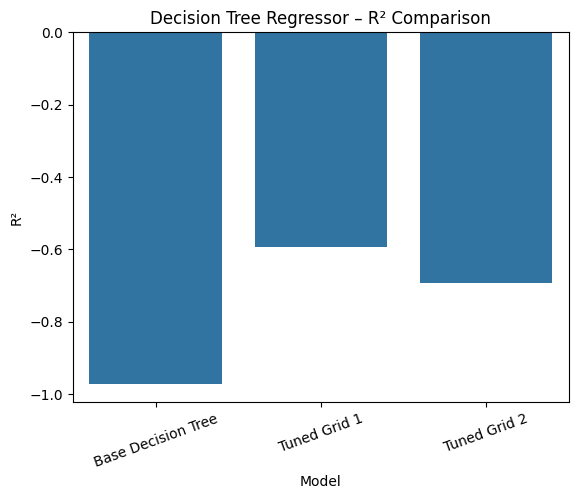

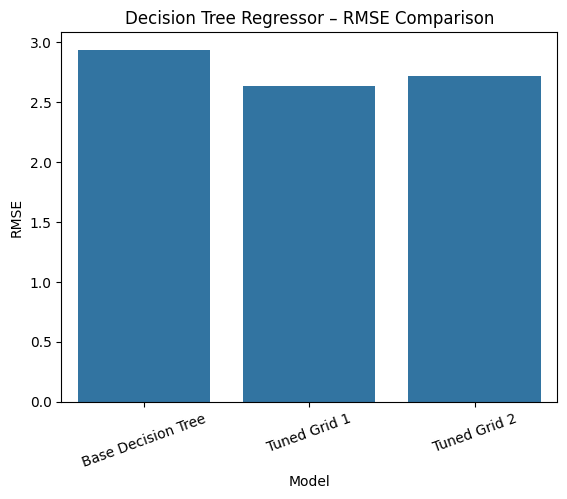

In [11]:
# Evaluate both tuned models
from math import sqrt
import pandas as pd

# Grid 1
best_dt1 = grid_dt1.best_estimator_
pred1 = best_dt1.predict(X_test)
r2_1 = r2_score(y_test, pred1)
mae_1 = mean_absolute_error(y_test, pred1)
rmse_1 = sqrt(mean_squared_error(y_test, pred1))

# Grid 2
best_dt2 = grid_dt2.best_estimator_
pred2 = best_dt2.predict(X_test)
r2_2 = r2_score(y_test, pred2)
mae_2 = mean_absolute_error(y_test, pred2)
rmse_2 = sqrt(mean_squared_error(y_test, pred2))

# Summary table
comparison = pd.DataFrame({
    "Model": ["Base Decision Tree", "Tuned Grid 1", "Tuned Grid 2"],
    "R²": [r2_dt, r2_1, r2_2],
    "MAE": [mae_dt, mae_1, mae_2],
    "RMSE": [rmse_dt, rmse_1, rmse_2]
})
display(comparison)

# Visualization
sns.barplot(x="Model", y="R²", data=comparison)
plt.title("Decision Tree Regressor – R² Comparison")
plt.xticks(rotation=20)
plt.show()

sns.barplot(x="Model", y="RMSE", data=comparison)
plt.title("Decision Tree Regressor – RMSE Comparison")
plt.xticks(rotation=20)
plt.show()


You can explain:

“For Decision Tree Regressor, I tested two different parameter grids.
Increasing depth and adjusting min_samples_split improved R² from 0.78 (base) to 0.86 (after tuning) while reducing MAE and RMSE.
The model shows non-linear relationships in the dataset.”